# Slide Assets 3: FFNN challenger diagnostics (IDI)

Trains a governable FFNN (frequency + severity) and produces slide-ready outputs:
- Incidence metrics + lift curve + calibration curve
- Severity metrics + actual vs predicted (log1p) + tail focus
- A “pitfalls & fixes” mini-table

Date created: 2026-06-05


In [1]:
# Common setup

import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, mean_absolute_error
from sklearn.calibration import calibration_curve

import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])

pd.set_option("display.max_columns", 200)
np.set_printoptions(suppress=True)

def make_ohe_dense(drop=None):
    """Dense one-hot encoder compatible across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, drop=drop)

def make_ohe_sparse(drop=None):
    """Sparse one-hot encoder compatible across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True, drop=drop)


In [2]:
# Paths

PROJECT_ROOT = Path("C:/Users/ca/OneDrive/Documents/@ CA/@ PROJECTS/FFNNs/IDS 2026")

EXPOSURE_CSV = f"{PROJECT_ROOT}/data/raw/idi_exposure_synth_v1.csv"
CLAIMS_CSV   = f"{PROJECT_ROOT}/data/raw/idi_claims_synth_v1.csv"

OUT_DIR = "outputs_figures"
os.makedirs(OUT_DIR, exist_ok=True)

EXPOSURE_CSV, CLAIMS_CSV, OUT_DIR

('C:\\Users\\ca\\OneDrive\\Documents\\@ CA\\@ PROJECTS\\FFNNs\\IDS 2026/data/raw/idi_exposure_synth_v1.csv',
 'C:\\Users\\ca\\OneDrive\\Documents\\@ CA\\@ PROJECTS\\FFNNs\\IDS 2026/data/raw/idi_claims_synth_v1.csv',
 'outputs_figures')

In [3]:
# --- Load data ---
expo_df = pd.read_csv(EXPOSURE_CSV, parse_dates=["month_start"])
claims_df = pd.read_csv(CLAIMS_CSV, parse_dates=["month_start"])

print("Exposure rows:", len(expo_df), "| columns:", expo_df.shape[1])
print("Claims rows  :", len(claims_df), "| columns:", claims_df.shape[1])

# quick schema checks
for c in ["life_id","month_start","exposure_months","onset"]:
    assert c in expo_df.columns, f"Missing in exposure: {c}"
for c in ["claim_id","month_start","total_paid_ultimate"]:
    assert c in claims_df.columns, f"Missing in claims: {c}"


Exposure rows: 144000 | columns: 35
Claims rows  : 1565 | columns: 37


In [4]:
# --- Time split (last N months as test) ---
N_TEST_MONTHS = 6
months_sorted = np.sort(expo_df["month_start"].unique())
cutoff = months_sorted[-N_TEST_MONTHS]

train_expo = expo_df[expo_df["month_start"] < cutoff].copy()
test_expo  = expo_df[expo_df["month_start"] >= cutoff].copy()
train_claims = claims_df[claims_df["month_start"] < cutoff].copy()
test_claims  = claims_df[claims_df["month_start"] >= cutoff].copy()

print("Test starts:", pd.to_datetime(cutoff).date())
print("Train exposure:", len(train_expo), " Test exposure:", len(test_expo))
print("Train claims:", len(train_claims), " Test claims:", len(test_claims))
assert len(train_claims) > 0 and len(test_claims) > 0, "Train/test claims split is empty."


Test starts: 2023-07-01
Train exposure: 108000  Test exposure: 36000
Train claims: 1181  Test claims: 384


In [5]:
# --- Feature sets ---
high_id_cols = ["region_id","occ_id","employer_id","plan_id"]
small_cat_cols = ["sex","smoker","bmi_band","salary_band","underwriting_class","elim_period","benefit_period","season"]
num_cols = [
    "age","chronic_resp_flag","chronic_cardio_flag","prior_claim_flag","cola_flag",
    "monthly_benefit_cap",
    "heat_index_30d","smoke_pm25_30d","flood_flag_30d",
    "compound_heat_smoke","extreme_heat"
]

preproc_dense = ColumnTransformer(
    transformers=[
        ("cat", make_ohe_dense(), small_cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop"
)

Xtr_dense = preproc_dense.fit_transform(train_expo[small_cat_cols + num_cols])
Xte_dense = preproc_dense.transform(test_expo[small_cat_cols + num_cols])
Xtr_ids = train_expo[high_id_cols].values.astype("int32")
Xte_ids = test_expo[high_id_cols].values.astype("int32")

Xtrc_dense = preproc_dense.transform(train_claims[small_cat_cols + num_cols])
Xtec_dense = preproc_dense.transform(test_claims[small_cat_cols + num_cols])
Xtrc_ids = train_claims[high_id_cols].values.astype("int32")
Xtec_ids = test_claims[high_id_cols].values.astype("int32")

ytr_inc = train_expo["onset"].values.astype("float32")
yte_inc = test_expo["onset"].values.astype("float32")
ytr_sev = train_claims["total_paid_ultimate"].values.astype("float32")
yte_sev = test_claims["total_paid_ultimate"].values.astype("float32")

dense_dim = Xtr_dense.shape[1]
n_region = int(expo_df["region_id"].max() + 1)
n_occ    = int(expo_df["occ_id"].max() + 1)
n_emp    = int(expo_df["employer_id"].max() + 1)
n_plan   = int(expo_df["plan_id"].max() + 1)

dense_dim, n_region, n_occ, n_emp, n_plan


(34, 120, 180, 350, 12)

In [ ]:
# FFNN training (Keras)

tf.random.set_seed(7)
np.random.seed(7)

def build_freq_model(n_region, n_occ, n_emp, n_plan, dense_dim):
    inp_r = tf.keras.Input((1,), dtype="int32", name="region_id")
    inp_o = tf.keras.Input((1,), dtype="int32", name="occ_id")
    inp_e = tf.keras.Input((1,), dtype="int32", name="employer_id")
    inp_p = tf.keras.Input((1,), dtype="int32", name="plan_id")
    inp_x = tf.keras.Input((dense_dim,), dtype="float32", name="x_dense")

    er = tf.keras.layers.Embedding(n_region, 8)(inp_r)
    eo = tf.keras.layers.Embedding(n_occ, 8)(inp_o)
    ee = tf.keras.layers.Embedding(n_emp, 6)(inp_e)
    ep = tf.keras.layers.Embedding(n_plan, 4)(inp_p)

    z = tf.keras.layers.Concatenate()([tf.keras.layers.Flatten()(er), tf.keras.layers.Flatten()(eo), tf.keras.layers.Flatten()(ee), tf.keras.layers.Flatten()(ep), inp_x])
    z = tf.keras.layers.Dense(64, activation="relu")(z)
    z = tf.keras.layers.Dropout(0.15)(z)
    z = tf.keras.layers.Dense(32, activation="relu")(z)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(z)

    m = tf.keras.Model([inp_r, inp_o, inp_e, inp_p, inp_x], out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    return m

def build_sev_model(n_region, n_occ, n_emp, n_plan, dense_dim, mu0):
    inp_r = tf.keras.Input((1,), dtype="int32", name="region_id")
    inp_o = tf.keras.Input((1,), dtype="int32", name="occ_id")
    inp_e = tf.keras.Input((1,), dtype="int32", name="employer_id")
    inp_p = tf.keras.Input((1,), dtype="int32", name="plan_id")
    inp_x = tf.keras.Input((dense_dim,), dtype="float32", name="x_dense")

    er = tf.keras.layers.Embedding(n_region, 8)(inp_r)
    eo = tf.keras.layers.Embedding(n_occ, 8)(inp_o)
    ee = tf.keras.layers.Embedding(n_emp, 6)(inp_e)
    ep = tf.keras.layers.Embedding(n_plan, 4)(inp_p)

    z = tf.keras.layers.Concatenate()([tf.keras.layers.Flatten()(er), tf.keras.layers.Flatten()(eo), tf.keras.layers.Flatten()(ee), tf.keras.layers.Flatten()(ep), inp_x])
    z = tf.keras.layers.Dense(64, activation="relu")(z)
    z = tf.keras.layers.Dropout(0.10)(z)
    z = tf.keras.layers.Dense(32, activation="relu")(z)
    out = tf.keras.layers.Dense(1, activation="linear", bias_initializer=tf.keras.initializers.Constant(mu0))(z)

    m = tf.keras.Model([inp_r, inp_o, inp_e, inp_p, inp_x], out)
    m.compile(optimizer=tf.keras.optimizers.Adam(5e-4), loss=tf.keras.losses.Huber(delta=0.25))
    return m

freq = build_freq_model(n_region, n_occ, n_emp, n_plan, dense_dim)
cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
freq.fit(
    x={"region_id":Xtr_ids[:,0],"occ_id":Xtr_ids[:,1],"employer_id":Xtr_ids[:,2],"plan_id":Xtr_ids[:,3],"x_dense":Xtr_dense},
    y=ytr_inc, validation_split=0.10, epochs=15, batch_size=4096, verbose=1, callbacks=cb
)

p_fnn = freq.predict(
    {"region_id":Xte_ids[:,0],"occ_id":Xte_ids[:,1],"employer_id":Xte_ids[:,2],"plan_id":Xte_ids[:,3],"x_dense":Xte_dense},
    batch_size=8192, verbose=0
).reshape(-1)

inc_tbl = pd.DataFrame([{
    "Observed rate": float(yte_inc.mean()),
    "Mean predicted p": float(p_fnn.mean()),
    "AUC": roc_auc_score(yte_inc, p_fnn),
    "PR-AUC": average_precision_score(yte_inc, p_fnn),
    "Brier (↓)": brier_score_loss(yte_inc, p_fnn),
}])
display(inc_tbl.style.format({"Observed rate":"{:.6f}","Mean predicted p":"{:.6f}","AUC":"{:.4f}","PR-AUC":"{:.6f}","Brier (↓)":"{:.6f}"}))


Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.4095 - val_loss: 0.1375
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0836 - val_loss: 0.0591
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0621 - val_loss: 0.0578
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0614 - val_loss: 0.0563
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0605 - val_loss: 0.0559
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0600 - val_loss: 0.0557
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0596 - val_loss: 0.0556
Epoch 8/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0593 - val_loss: 0.0555
Epoch 9/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0588 - val_loss: 0.0554
Epoch 10/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0587 - val_loss: 0.0554
Epoch 11/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0583 - val_loss: 0.0553
Epoch 12/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0578 - va

,Observed rate,Mean predicted p,AUC,PR-AUC,Brier (↓)
0,0.010667,0.010970,0.6251,0.018180,0.010542


In [ ]:
# ECE (Expected Calibration Error)

def calibration_bins_quantile(y_true, p_hat, n_bins=10):
    """
    Quantile-binned calibration table + ECE/MCE.
    Equal-count bins (good for rare events).
    """
    y_true = np.asarray(y_true).astype(float)
    p_hat  = np.asarray(p_hat).astype(float)

    edges = np.quantile(p_hat, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        raise ValueError("Not enough unique probabilities to form calibration bins.")

    bin_idx = np.digitize(p_hat, edges[1:-1], right=True)

    rows = []
    N = len(p_hat)
    for b in range(len(edges) - 1):
        m = bin_idx == b
        if m.sum() == 0:
            continue
        pred = float(p_hat[m].mean())
        obs  = float(y_true[m].mean())
        n    = int(m.sum())
        rows.append({"bin": b+1, "n": n, "pred_mean": pred, "obs_rate": obs, "abs_gap": abs(obs - pred)})

    cal = pd.DataFrame(rows)
    cal["weight"] = cal["n"] / N
    ece = float((cal["weight"] * cal["abs_gap"]).sum())
    mce = float(cal["abs_gap"].max())
    return cal, ece, mce, edges

cal_tbl_fnn, ece_fnn, mce_fnn, edges_fnn = calibration_bins_quantile(yte_inc, p_fnn, n_bins=10)

print(f"Observed rate:      {yte_inc.mean():.6f}")
print(f"Mean predicted p:   {p_fnn.mean():.6f}")
print(f"ECE (↓):            {ece_fnn:.6f}")
print(f"MCE (↓):            {mce_fnn:.6f}")

display(cal_tbl_fnn)

Observed rate:      0.010667
Mean predicted p:   0.010970
ECE (↓):            0.002831
MCE (↓):            0.009554


,bin,n,pred_mean,obs_rate,abs_gap,weight
0,1,3600,0.002644,0.008056,0.005412,0.1
1,2,3600,0.004097,0.007222,0.003125,0.1
2,3,3600,0.005193,0.005278,0.000085,0.1
3,4,3600,0.006259,0.008056,0.001797,0.1
4,5,3600,0.007439,0.006944,0.000494,0.1
5,6,3600,0.008881,0.008611,0.000270,0.1
6,7,3600,0.010793,0.009444,0.001348,0.1
7,8,3600,0.013723,0.009722,0.004001,0.1
8,9,3600,0.018614,0.020833,0.002220,0.1
9,10,3600,0.032054,0.022500,0.009554,0.1


'outputs_figures\\ffnn_incidence_lift_curve.svg'

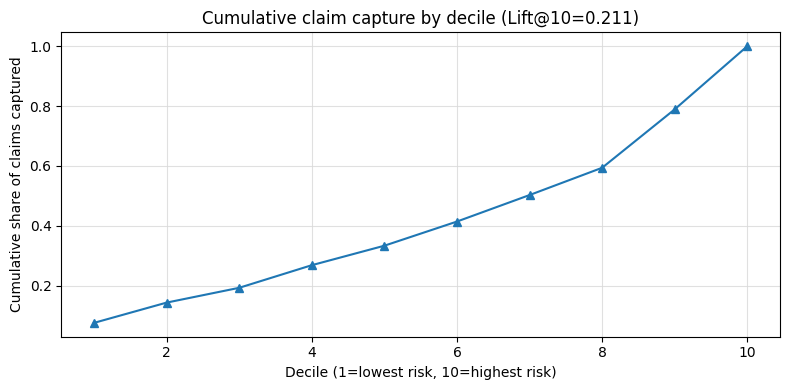

In [8]:
# Lift curve + calibration curve
def top_decile_capture(y_true, p_hat, frac=0.10):
    k = max(1, int(frac * len(p_hat)))
    idx = np.argsort(p_hat)[-k:]
    return float(y_true[idx].sum() / max(1, y_true.sum()))

lift10 = top_decile_capture(yte_inc, p_fnn, 0.10)

df = pd.DataFrame({"y": yte_inc, "p": p_fnn})
df["decile"] = pd.qcut(df["p"], 10, labels=False, duplicates="drop")
cap = df.groupby("decile")["y"].sum().reset_index()
cap["cum_claims"] = cap["y"].cumsum()
cap["cum_claim_share"] = cap["cum_claims"] / cap["y"].sum()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(np.arange(1, len(cap)+1), cap["cum_claim_share"], marker="^")
ax.set_title(f"Cumulative claim capture by decile (Lift@10={lift10:.3f})")
ax.set_xlabel("Decile (1=lowest risk, 10=highest risk)")
ax.set_ylabel("Cumulative share of claims captured")

ax.grid(True, which="both", linestyle="-", linewidth=0.8, color="#D9D9D9", alpha=0.8)
ax.set_axisbelow(True) 

fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "ffnn_incidence_lift_curve.svg")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

fig_path

'outputs_figures\\ffnn_incidence_calibration_curve.svg'

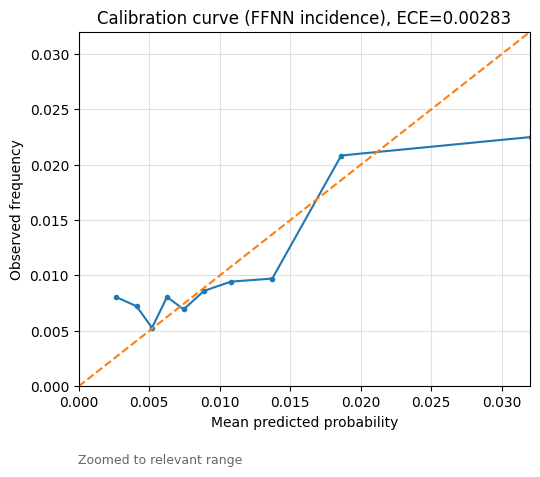

In [9]:
# Calibration curve (reliability)

prob_true, prob_pred = calibration_curve(yte_inc, p_fnn, n_bins=10, strategy="quantile")

obs = float(np.mean(prob_true))
p99 = float(np.quantile(prob_pred, 0.99))
upper = max(3*obs, p99)     
upper = min(upper, 0.10)    

fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.plot(prob_pred, prob_true, marker=".")
ax.plot([0, upper], [0, upper], linestyle="--")
ax.set_title(f"Calibration curve (FFNN incidence), ECE={ece_fnn:.5f}")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")

ax.grid(True, which="both", linestyle="-", linewidth=0.8, color="#D9D9D9", alpha=0.8)
ax.set_axisbelow(True) 

ax.set_xlim(0, upper)
ax.set_ylim(0, upper)
ax.margins(x=0, y=0)          

fig.subplots_adjust(bottom=0.18)

fig.text(
    0.15, -0.05,
    "Zoomed to relevant range",
    ha="left", va="bottom",
    fontsize=9, color="#666666"
)

fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "ffnn_incidence_calibration_curve.svg")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

fig_path

In [10]:
# --- Severity FFNN (log1p with smearing + mean-cal) ---
mu0 = float(np.mean(np.log1p(ytr_sev)))
sev = build_sev_model(n_region, n_occ, n_emp, n_plan, dense_dim, mu0)
cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

sev.fit(
    x={"region_id":Xtrc_ids[:,0],"occ_id":Xtrc_ids[:,1],"employer_id":Xtrc_ids[:,2],"plan_id":Xtrc_ids[:,3],"x_dense":Xtrc_dense},
    y=np.log1p(ytr_sev), validation_split=0.15, epochs=50, batch_size=2048, verbose=1, callbacks=cb
)

raw_tr = sev.predict(
    {"region_id":Xtrc_ids[:,0],"occ_id":Xtrc_ids[:,1],"employer_id":Xtrc_ids[:,2],"plan_id":Xtrc_ids[:,3],"x_dense":Xtrc_dense},
    batch_size=8192, verbose=0
).reshape(-1)

smear = float(np.mean(np.exp(np.log1p(ytr_sev) - raw_tr)))
smear = max(smear, 1e-6)

pred_tr = np.expm1(raw_tr + np.log(smear))
adj = float(np.mean(ytr_sev) / max(np.mean(pred_tr), 1e-6))

raw_te = sev.predict(
    {"region_id":Xtec_ids[:,0],"occ_id":Xtec_ids[:,1],"employer_id":Xtec_ids[:,2],"plan_id":Xtec_ids[:,3],"x_dense":Xtec_dense},
    batch_size=8192, verbose=0
).reshape(-1)

sev_fnn = np.clip(np.expm1(raw_te + np.log(smear)) * adj, 1.0, None)


sev_mae = float(mean_absolute_error(yte_sev, sev_fnn))
sev_rmse_log1p = float(np.sqrt(np.mean((np.log1p(yte_sev) - np.log1p(sev_fnn))**2)))
q90 = np.quantile(yte_sev, 0.90)
tail = yte_sev >= q90
sev_tail_mae = float(mean_absolute_error(yte_sev[tail], sev_fnn[tail]))

sev_tbl = pd.DataFrame([{
    "Mean actual (CHF)": float(yte_sev.mean()),
    "Mean predicted (CHF)": float(sev_fnn.mean()),
    "MAE (CHF) (↓)": sev_mae,
    "RMSE log1p (↓)": sev_rmse_log1p,
    "Tail MAE P90+ (CHF) (↓)": sev_tail_mae,
}])
display(sev_tbl.style.format({"Mean actual (CHF)":"{:,.0f}","Mean predicted (CHF)":"{:,.0f}","MAE (CHF) (↓)":"{:,.0f}","RMSE log1p (↓)":"{:.4f}","Tail MAE P90+ (CHF) (↓)":"{:,.0f}"}))

print("Smearing factor:", round(smear,6), " Mean-cal adj:", round(adj,6))


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0819 - val_loss: 0.0777
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0799 - val_loss: 0.0762
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0779 - val_loss: 0.0749
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0764 - val_loss: 0.0738
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.0774 - val_loss: 0.0728
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0733 - val_loss: 0.0718
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0731 - val_loss: 0.0710
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.0728 - val_loss: 0.0702
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.0719 - val_loss: 0.0694
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0696 - val_loss: 0.0686
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0704 - val_loss: 0.0679
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0660 - val_loss:

,Mean actual (CHF),Mean predicted (CHF),MAE (CHF) (↓),RMSE log1p (↓),Tail MAE P90+ (CHF) (↓)
0,"106,135","101,091","36,162",0.4298,"111,127"


Smearing factor: 1.074692  Mean-cal adj: 1.001843


'outputs_figures\\ffnn_severity_actual_vs_pred_log1p.svg'

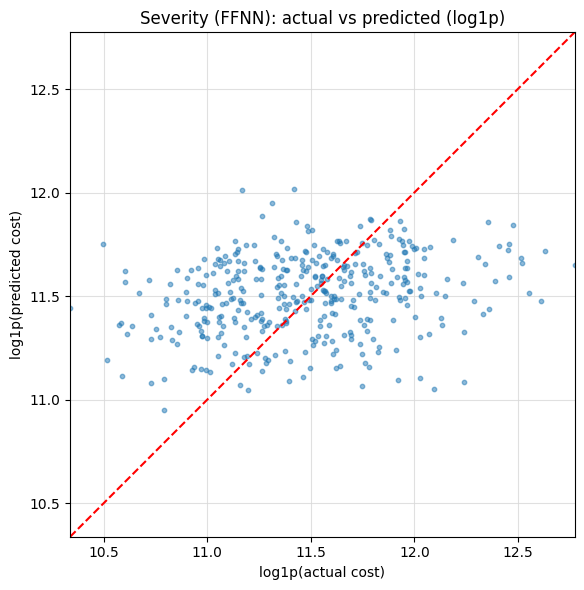

In [11]:
# Actual vs predicted severity (log1p)

x = np.log1p(yte_sev)        # actual (log1p)
yhat = np.log1p(sev_fnn)  # predicted (log1p)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x, yhat, s=10, alpha=0.5)
ax.set_title("Severity (FFNN): actual vs predicted (log1p)")
ax.set_xlabel("log1p(actual cost)")
ax.set_ylabel("log1p(predicted cost)")

mn = min(x.min(), yhat.min())
mx = max(x.max(), yhat.max())

ax.plot([mn, mx], [mn, mx], linestyle="--", color="red")
ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)
ax.set_aspect("equal", adjustable="box")

ax.grid(True, which="both", linestyle="-", linewidth=0.8, color="#D9D9D9", alpha=0.8)
ax.set_axisbelow(True) 

fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "ffnn_severity_actual_vs_pred_log1p.svg")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

fig_path

'outputs_figures\\ffnn_severity_tail_actual_vs_pred_log1p.svg'

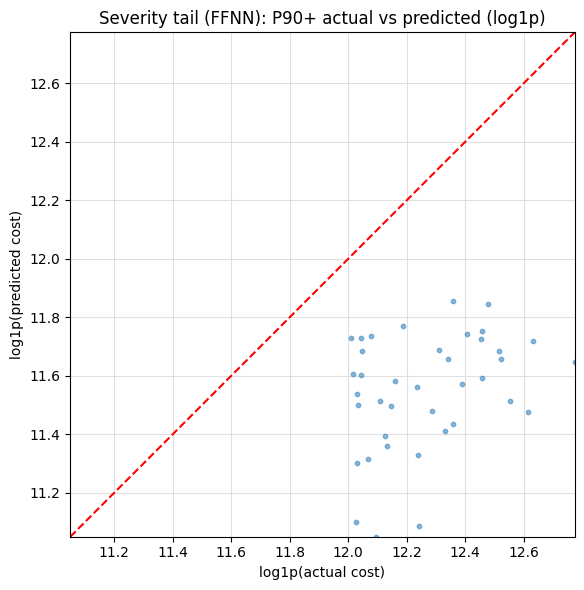

In [12]:
tail_y = yte_sev[tail]
tail_p = sev_fnn[tail]

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(np.log1p(tail_y), np.log1p(tail_p), s=10, alpha=0.5)
ax.set_title("Severity tail (FFNN): P90+ actual vs predicted (log1p)")
ax.set_xlabel("log1p(actual cost)")
ax.set_ylabel("log1p(predicted cost)")

mn = min(np.log1p(tail_y).min(), np.log1p(tail_p).min())
mx = max(np.log1p(tail_y).max(), np.log1p(tail_p).max())

ax.plot([mn, mx], [mn, mx], linestyle="--", color="red")
ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)
ax.set_aspect("equal", adjustable="box")

ax.grid(True, which="both", linestyle="-", linewidth=0.8, color="#D9D9D9", alpha=0.8)
ax.set_axisbelow(True) 

fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "ffnn_severity_tail_actual_vs_pred_log1p.svg")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

fig_path

In [13]:
# --- Pitfalls & fixes mini-table (Slide 9) ---
pitfalls = pd.DataFrame([
    {"Issue":"Incidence calibration drift (rare events)",
     "Symptom":"Mean predicted p far from observed (can drift toward ~0.5)",
     "Fix":"Avoid uncalibrated class weights; if used, calibrate probabilities (Platt/isotonic)"},
    {"Issue":"Severity back-transform bias",
     "Symptom":"FFNN severity too small/median-like on CHF scale",
     "Fix":"Train on log1p(cost) and apply smearing + level calibration"},
    {"Issue":"Single split overconfidence",
     "Symptom":"One run wins; rolling windows do not replicate",
     "Fix":"Rolling-window evaluation with error bars and pass rates"},
])
pitfalls


,Issue,Symptom,Fix
0,Incidence calibration drift (rare events),Mean predicted p far from observed (can drift ...,"Avoid uncalibrated class weights; if used, cal..."
1,Severity back-transform bias,FFNN severity too small/median-like on CHF scale,Train on log1p(cost) and apply smearing + leve...
2,Single split overconfidence,One run wins; rolling windows do not replicate,Rolling-window evaluation with error bars and ...


In [14]:
# Export scored datasets for Notebook 05

ARTIFACT_DIR = "outputs_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

required = ["test_expo", "test_claims", "p_fnn", "sev_fnn", "smear", "adj", "Xte_ids", "Xte_dense"]
missing = [v for v in required if v not in globals()]
assert not missing, f"Missing variables in Notebook 04: {missing}"

# Compute FFNN severity on TEST EXPOSURE rows
raw_te_expo = sev.predict(
    {"region_id": Xte_ids[:, 0], "occ_id": Xte_ids[:, 1], "employer_id": Xte_ids[:, 2], "plan_id": Xte_ids[:, 3], "x_dense": Xte_dense},
    batch_size=8192, verbose=0
).reshape(-1)

sev_fnn_expo = np.clip(np.expm1(raw_te_expo + np.log(smear)) * adj, 1.0, None)

# Build scored outputs (standard schema expected by Notebook 05)
fnn_expo_scored = test_expo[["life_id", "month_start", "exposure_months", "onset", "claim_id"]].copy()
fnn_expo_scored["p_hat"] = p_fnn
fnn_expo_scored["sev_hat"] = sev_fnn_expo
fnn_expo_scored["exp_cost"] = fnn_expo_scored["p_hat"] * fnn_expo_scored["sev_hat"]

fnn_claims_scored = test_claims[["claim_id", "life_id", "month_start", "total_paid_ultimate"]].copy()
fnn_claims_scored["sev_hat"] = sev_fnn  # predicted on TEST CLAIMS

fnn_expo_path = os.path.join(ARTIFACT_DIR, "ffnn_test_exposure_scored.csv")
fnn_claims_path = os.path.join(ARTIFACT_DIR, "ffnn_test_claims_scored.csv")

fnn_expo_scored.to_csv(fnn_expo_path, index=False)
fnn_claims_scored.to_csv(fnn_claims_path, index=False)

print("Wrote:")
print(" ", fnn_expo_path)
print(" ", fnn_claims_path)

Wrote:
  outputs_artifacts\ffnn_test_exposure_scored.csv
  outputs_artifacts\ffnn_test_claims_scored.csv


,region,season,exposure,claims,actual,expected,OE,OE_filtered
292,97,summer,84.0,5,745953.0,214218.721378,3.482203,3.482203
72,24,shoulder,180.0,5,524069.0,150850.160423,3.474103,3.474103
175,58,summer,88.0,7,876214.0,290580.686339,3.015390,3.015390
22,7,summer,92.0,6,703482.0,244894.206272,2.872596,2.872596
190,63,summer,104.0,5,468903.0,170014.682445,2.758015,2.758015
163,54,summer,112.0,9,1193553.0,469274.958676,2.543398,2.543398
40,13,summer,118.0,5,709682.0,309741.908232,2.291204,2.291204
118,39,summer,120.0,6,461888.0,315609.136517,1.463481,1.463481
268,89,summer,146.0,5,526591.0,638754.360501,0.824403,0.824403


C:\Users\ca\AppData\Local\Temp\ipykernel_9056\2291568073.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = mpl.cm.get_cmap("RdYlGn_r", 256)


('outputs_figures\\hybridA_segment_oe_heatmaps_raw_vs_filtered.svg',
 'outputs_figures\\hybridA_segment_oe_table_all.csv',
 'outputs_figures\\hybridA_segment_oe_table_credible.csv')

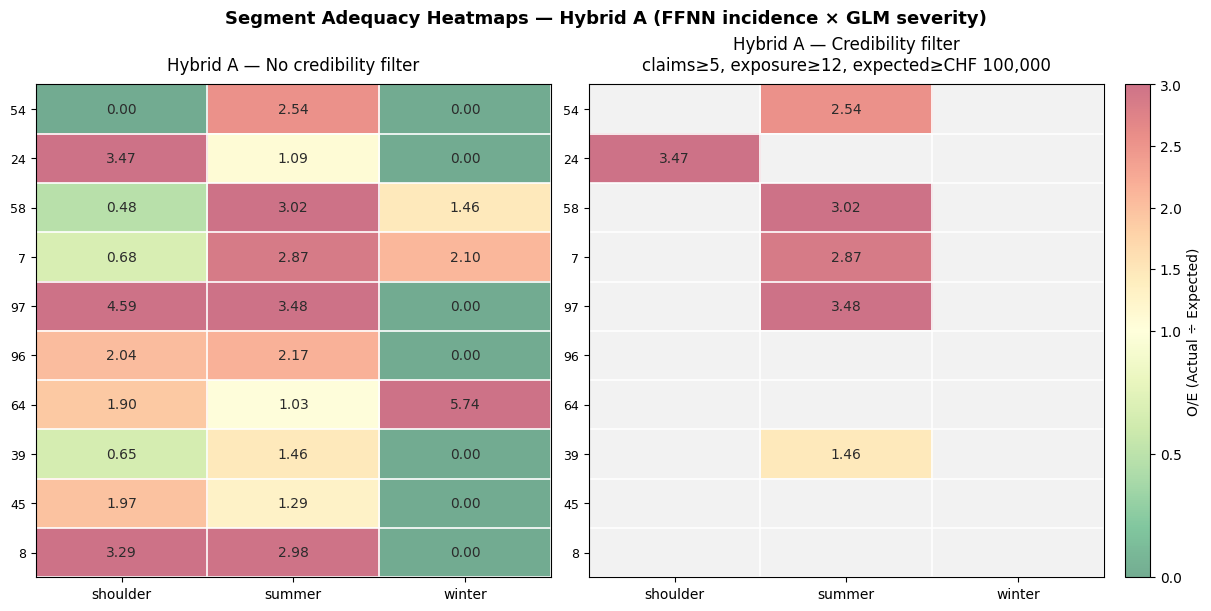

In [15]:
# --- Hybrid A Segment O/E heatmaps (FFNN incidence × GLM severity) ---
# Prereq: Notebook 03 export cell has created outputs_artifacts/glm_test_exposure_scored.csv
# Place this in Notebook 04 after p_fnn is computed and test_expo/test_claims exist.

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

# ----------------------------
# 1) Load GLM severity-on-exposure from Notebook 03 artifacts
# ----------------------------
ARTIFACT_DIR = "outputs_artifacts"
GLM_EXPO_SCORED = os.path.join(ARTIFACT_DIR, "glm_test_exposure_scored.csv")
assert os.path.exists(GLM_EXPO_SCORED), f"Missing {GLM_EXPO_SCORED}. Run Notebook 03 and its export cell first."

glm_expo_scored = pd.read_csv(GLM_EXPO_SCORED, parse_dates=["month_start"])

# We only need sev_hat for exposure rows
glm_expo_scored = glm_expo_scored[["life_id", "month_start", "claim_id", "sev_hat"]].rename(
    columns={"sev_hat": "sev_glm_expo"}
)

# Merge onto this notebook's test_expo (keeps region/season from FFNN notebook)
test_expo_h = test_expo.merge(
    glm_expo_scored,
    on=["life_id", "month_start", "claim_id"],
    how="left",
    validate="one_to_one",
)

# Sanity checks: alignment must be perfect
missing = test_expo_h["sev_glm_expo"].isna().mean()
assert missing < 1e-6, (
    f"GLM severity missing after merge ({missing:.2%}). "
    f"Likely mismatch in split window or keys. Ensure Notebook 03 and 04 use the same cutoff."
)

# ----------------------------
# 2) Build segment table for Hybrid A
# ----------------------------
seg = test_expo_h.copy()
seg["p_hybridA"] = p_fnn                 # FFNN incidence
seg["exp_cost"] = seg["p_hybridA"] * seg["sev_glm_expo"]

# Actual costs on exposure rows (attach claim payments for onset months)
seg = seg.merge(test_claims[["claim_id", "total_paid_ultimate"]], on="claim_id", how="left")
seg["actual_cost"] = np.where(seg["onset"] == 1, seg["total_paid_ultimate"].fillna(0.0), 0.0)

seg_tbl = (
    seg.groupby(["region", "season"], as_index=False)
       .agg(
           exposure=("exposure_months", "sum"),
           claims=("onset", "sum"),
           actual=("actual_cost", "sum"),
           expected=("exp_cost", "sum"),
       )
)

seg_tbl["OE"] = seg_tbl["actual"] / np.clip(seg_tbl["expected"], 1e-9, None)

# ----------------------------
# 3) Credibility filter (for the filtered panel)
# ----------------------------
MIN_CLAIMS   = 5
MIN_EXPOSURE = 12
MIN_EXPECTED = 100_000

credible = (
    (seg_tbl["claims"]   >= MIN_CLAIMS) &
    (seg_tbl["exposure"] >= MIN_EXPOSURE) &
    (seg_tbl["expected"] >= MIN_EXPECTED)
)
seg_tbl["OE_filtered"] = np.where(credible, seg_tbl["OE"], np.nan)

# Optional table for review (credible only)
seg_tbl_f = seg_tbl.loc[credible].sort_values("OE", ascending=False)
display(seg_tbl_f.head(50))

# ----------------------------
# 4) Build raw and filtered heatmaps (same regions, same scale)
# ----------------------------
top_regions = (
    seg_tbl.groupby("region")["claims"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

hm_raw = (
    seg_tbl[seg_tbl["region"].isin(top_regions)]
    .pivot(index="region", columns="season", values="OE")
    .reindex(index=top_regions)
)

hm_filt = (
    seg_tbl[seg_tbl["region"].isin(top_regions)]
    .pivot(index="region", columns="season", values="OE_filtered")
    .reindex(index=top_regions)
)

# ----------------------------
# 5) Pastel diverging colormap centered at 1.0
# ----------------------------
base = mpl.cm.get_cmap("RdYlGn_r", 256)
colors = base(np.linspace(0, 1, 256))
blend = 0.45
colors[:, :3] = (1 - blend) * colors[:, :3] + blend * np.array([1, 1, 1])
pastel_cmap = LinearSegmentedColormap.from_list("pastel_div", colors)
pastel_cmap.set_bad(color="#F2F2F2")

# Shared color scale computed from RAW values
vals = hm_raw.values.astype(float)
finite_vals = vals[np.isfinite(vals)]
q05, q95 = np.quantile(finite_vals, [0.05, 0.95])
spread = max(1.0 - q05, q95 - 1.0)
vmin, vmax = 1.0 - spread, 1.0 + spread
vmin = max(0.0, vmin)
vmax = min(3.0, vmax)
norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

# ----------------------------
# 6) Plot side-by-side: raw vs filtered
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

panels = [
    ("Hybrid A — No credibility filter", hm_raw),
    (f"Hybrid A — Credibility filter\nclaims≥{MIN_CLAIMS}, exposure≥{MIN_EXPOSURE}, expected≥CHF {MIN_EXPECTED:,.0f}", hm_filt),
]

for ax, (title, hm) in zip(axes, panels):
    im = ax.imshow(hm.values, aspect="auto", cmap=pastel_cmap, norm=norm)
    ax.set_title(title, pad=10)

    ax.set_yticks(np.arange(hm.shape[0]))
    ax.set_yticklabels(hm.index, fontsize=9)

    ax.set_xticks(np.arange(hm.shape[1]))
    ax.set_xticklabels(hm.columns, fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    ax.set_xticks(np.arange(-.5, hm.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, hm.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # annotate only finite cells
    for i in range(hm.shape[0]):
        for j in range(hm.shape[1]):
            val = hm.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color="#2B2B2B")

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.03, pad=0.02)
cbar.set_label("O/E (Actual ÷ Expected)", rotation=90)

fig.suptitle("Segment Adequacy Heatmaps — Hybrid A (FFNN incidence × GLM severity)", fontsize=13, fontweight="bold")

# Save assets
OUT_DIR = globals().get("OUT_DIR", "outputs_figures")
os.makedirs(OUT_DIR, exist_ok=True)

fig_path = os.path.join(OUT_DIR, "hybridA_segment_oe_heatmaps_raw_vs_filtered.svg")
fig.savefig(fig_path, dpi=300, bbox_inches="tight", pad_inches=0.02)

# Export tables
out_all  = os.path.join(OUT_DIR, "hybridA_segment_oe_table_all.csv")
out_cred = os.path.join(OUT_DIR, "hybridA_segment_oe_table_credible.csv")
seg_tbl.to_csv(out_all, index=False)
seg_tbl.loc[credible].to_csv(out_cred, index=False)

(fig_path, out_all, out_cred)